# 🩺 Diabetes Prediction System

### Machine Learning Based Diabetes Risk Prediction

**Domain:** Healthcare  
**Machine Learning:** Logistic Regression & Random Forest  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn


## 📌 Problem Statement

Diabetes is a common healthcare condition that can lead to serious
health complications if not identified early.

The objective of this project is to develop a machine learning based
Diabetes Prediction System that analyzes patient health information
and predicts whether the patient is likely to be classified as
Diabetic or Non-Diabetic.

The system uses patient attributes such as glucose level, BMI, age,
blood pressure, insulin level and other relevant medical features.

## 🎯 Objectives

- Analyze a diabetes dataset obtained from Kaggle.
- Clean and preprocess the patient data.
- Perform Exploratory Data Analysis (EDA).
- Train Logistic Regression and Random Forest models.
- Compare the performance of both models.
- Evaluate the final model using accuracy, precision, recall,
  F1-score, confusion matrix and ROC-AUC.
- Identify important features using Random Forest feature importance.
- Build a simple patient-input prediction system.

## 📂 Dataset

For this project, we use the **Pima Indians Diabetes Dataset**.

The dataset contains medical information about patients and an
`Outcome` column that represents the diabetes classification.

- `0` → Non-Diabetic
- `1` → Diabetic

### Input Features

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

### Target Variable

- Outcome

## 🔍 Understanding the Dataset

First, we inspect the dataset to understand its size, structure,
data types and statistical information.

The first few rows are displayed to verify that the dataset has
been loaded correctly.

## 📥 Dataset Loading

The diabetes dataset is loaded directly from the project's GitHub
repository using its raw CSV URL. This allows the notebook to be
reproduced in Google Colab without requiring a local dataset file.

In [96]:
import pandas as pd

url = "https://raw.githubusercontent.com/GunjanYadav09/diabetes-prediction-system/main/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
zero_counts = (df == 0).sum()

zero_counts

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [8]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [9]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


## 🧹 Data Cleaning

Before training the machine learning models, the dataset needs to be
cleaned.

Some columns contain `0` values that are not realistic measurements.
For example, a glucose level or BMI of zero is not meaningful for this
prediction problem.

These values are treated as missing values and replaced with the
median of the respective feature.

The `Pregnancies` and `Outcome` columns are not modified because
zero is a valid value for these columns.

In [10]:
columns_to_clean = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(df[columns_to_clean] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [11]:
import numpy as np

df[columns_to_clean] = df[columns_to_clean].replace(0, np.nan)

In [12]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [13]:
for column in columns_to_clean:
    df[column] = df[column].fillna(df[column].median())

In [14]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(768, 9)

In [20]:
columns_to_clean = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]


In [21]:
import numpy as np

df[columns_to_clean] = df[columns_to_clean].replace(0, np.nan)

In [22]:
for column in columns_to_clean:
    df[column] = df[column].fillna(df[column].median())

In [23]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.shape

(768, 9)

In [26]:
df["Outcome"].value_counts()


,count
Outcome,
0,500
1,268


## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset and
identify patterns and relationships between the patient features and
diabetes outcomes.

Different visualizations are used to analyze the distribution of the
target variable and important features such as Glucose, BMI and Age.

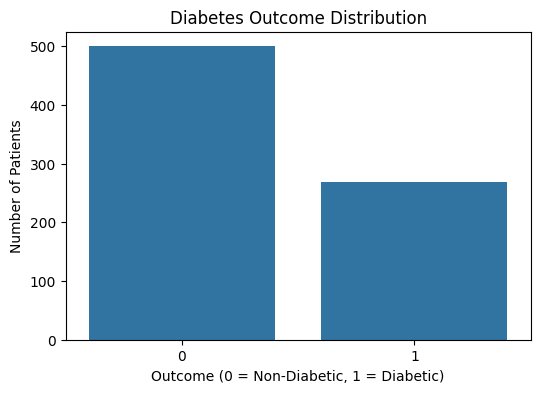

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

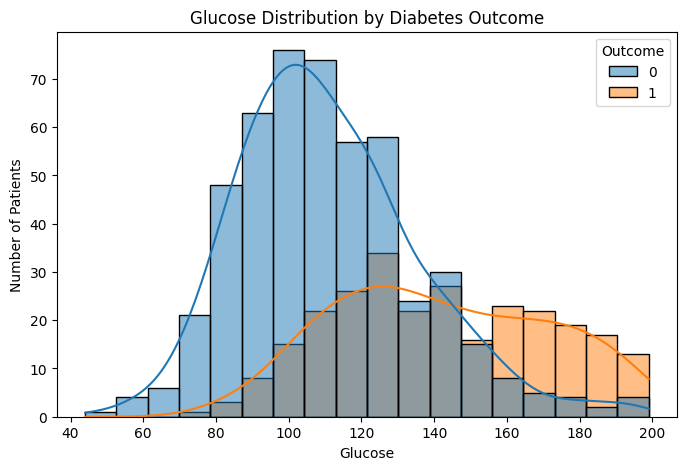

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Glucose",
    hue="Outcome",
    kde=True
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")

plt.show()

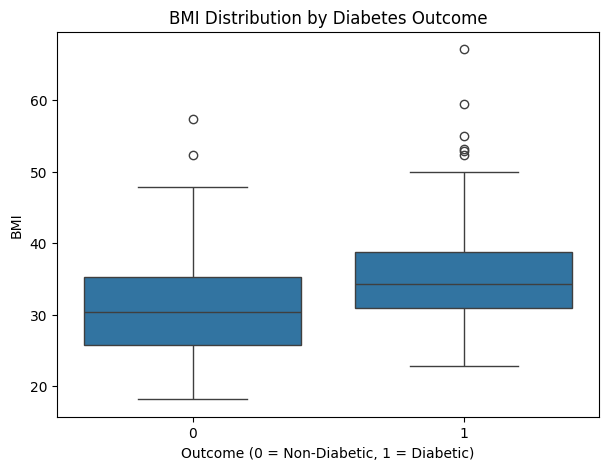

In [30]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("BMI")

plt.show()

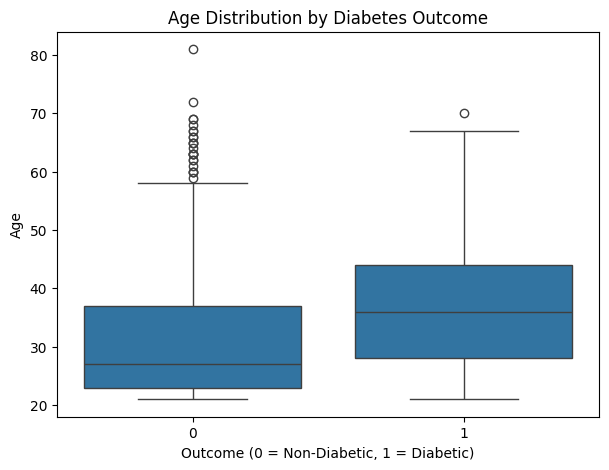

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Outcome",
    y="Age",
    data=df
)

plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Age")

plt.show()

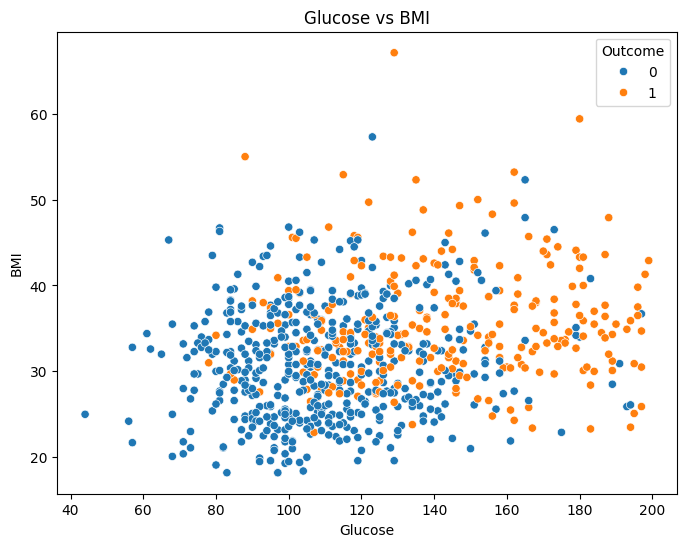

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

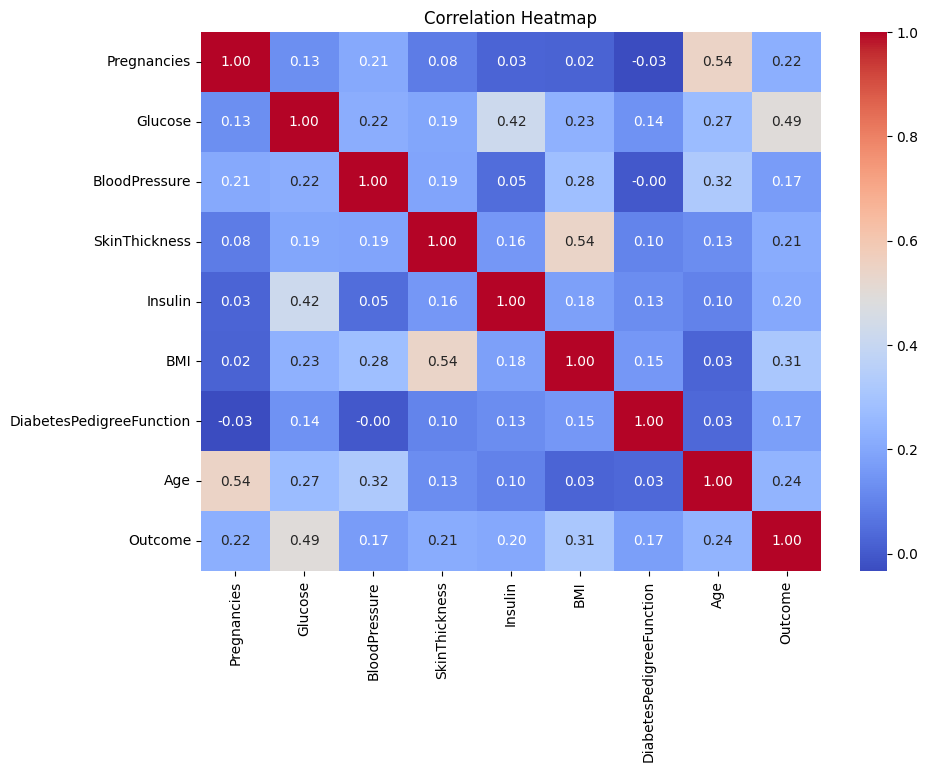

In [33]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [34]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [35]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## ⚙️ Preparing Data for Machine Learning

The `Outcome` column is the target variable that we want to predict.

- `0` represents Non-Diabetic.
- `1` represents Diabetic.

All other columns are used as input features for the machine learning
models.

The dataset is divided into training and testing sets. The training
data is used to train the models, while the testing data is used to
evaluate their performance.

In [36]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [37]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (768, 8)
y shape: (768,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [42]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

## 🤖 Model Training

In this step, two machine learning classification models are trained
to predict whether a patient is Diabetic or Non-Diabetic.

### 1. Logistic Regression

Logistic Regression is used as a baseline classification model.

### 2. Random Forest

Random Forest is used as the main prediction model.

In [43]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.7077922077922078


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [45]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      rf_accuracy)

Random Forest Accuracy: 0.7792207792207793


In [48]:
print("Logistic Regression Accuracy:",
      logistic_accuracy)

print("Random Forest Accuracy:",
      rf_accuracy)

Logistic Regression Accuracy: 0.7077922077922078
Random Forest Accuracy: 0.7792207792207793


## 📊 Model Comparison

The performance of Logistic Regression and Random Forest is compared
using test-set accuracy.

The model with better performance will be selected as the final model
for the diabetes prediction system.

In [49]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.707792
1,Random Forest,0.779221


In [50]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 📏 Feature Scaling

Feature scaling is applied before training the Logistic Regression
model so that features with different numerical ranges can be
processed more effectively.

Random Forest does not require feature scaling.

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non-Diabetic", "Diabetic"]
))


              precision    recall  f1-score   support

Non-Diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[88 12]
 [22 32]]


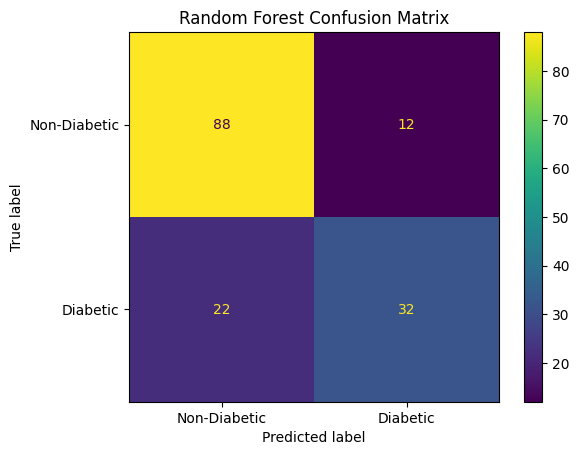

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [58]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 88
False Positives: 12
False Negatives: 22
True Positives : 32


In [59]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("Accuracy:", accuracy)

Accuracy: 0.7792207792207793


In [60]:
precision = tp / (tp + fp)

print("Precision:", precision)

Precision: 0.7272727272727273


In [61]:
recall = tp / (tp + fn)

print("Recall:", recall)

Recall: 0.5925925925925926


In [62]:
f1 = 2 * (precision * recall) / (precision + recall)

print("F1-score:", f1)

F1-score: 0.6530612244897959


In [63]:
print("Logistic Regression")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Non-Diabetic", "Diabetic"]
))


Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## 📈 Model Evaluation

The Random Forest model is evaluated using classification metrics
including accuracy, precision, recall and F1-score.

A confusion matrix is also used to identify correct and incorrect
predictions. The ROC-AUC score is calculated to measure the model's
ability to distinguish between Diabetic and Non-Diabetic patients.

In [64]:
print("Random Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non-Diabetic", "Diabetic"]
))

Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## ⭐ Feature Importance

Random Forest provides feature importance values that help identify
which input features contributed most to the model's predictions.

This analysis is used to understand the relative importance of the
patient features in the trained model.

In [65]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.274086
5,BMI,0.161903
6,DiabetesPedigreeFunction,0.125020
7,Age,0.112985
4,Insulin,0.091224
2,BloodPressure,0.083518
0,Pregnancies,0.080795
3,SkinThickness,0.070468


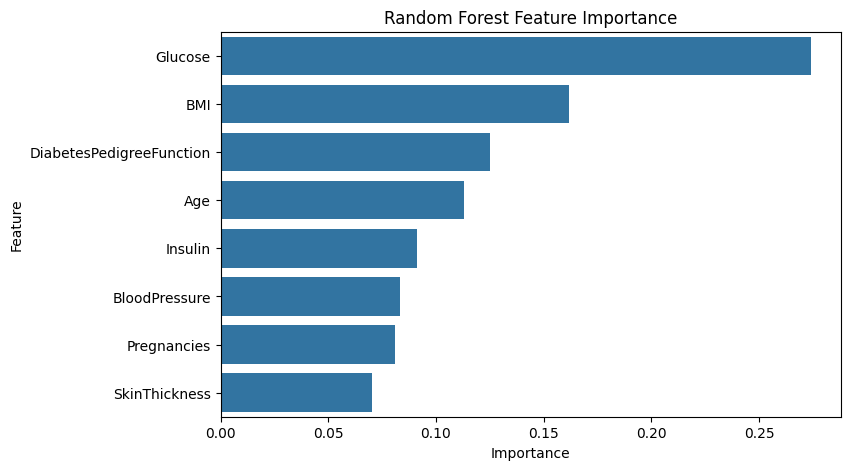

In [66]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [67]:
n_estimators=100

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [70]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [71]:
rf_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [72]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [73]:
print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Cross-Validation F1 Score:
0.651622274771716


In [74]:
best_rf = rf_grid.best_estimator_

In [75]:
y_pred_tuned = best_rf.predict(X_test)


In [76]:
from sklearn.metrics import accuracy_score, classification_report

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

Tuned Random Forest Accuracy: 0.7402597402597403


In [77]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Non-Diabetic", "Diabetic"]
))

              precision    recall  f1-score   support

Non-Diabetic       0.77      0.85      0.81       100
    Diabetic       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [78]:
from sklearn.metrics import roc_auc_score

y_probability = best_rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8207407407407407


In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        accuracy_score(y_test, y_pred_tuned)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.707792
1,Random Forest,0.779221
2,Tuned Random Forest,0.740260


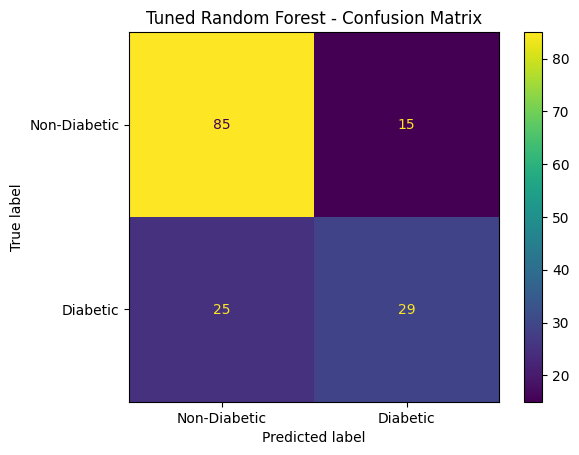

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [81]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Non-Diabetic", "Diabetic"]
))

              precision    recall  f1-score   support

Non-Diabetic       0.77      0.85      0.81       100
    Diabetic       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [82]:
import joblib

joblib.dump(best_rf, "diabetes_prediction_model.pkl")

['diabetes_prediction_model.pkl']

In [83]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        accuracy_score(y_test, y_pred_tuned)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.707792
1,Random Forest,0.779221
2,Tuned Random Forest,0.740260


In [84]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non-Diabetic", "Diabetic"]
))

              precision    recall  f1-score   support

Non-Diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



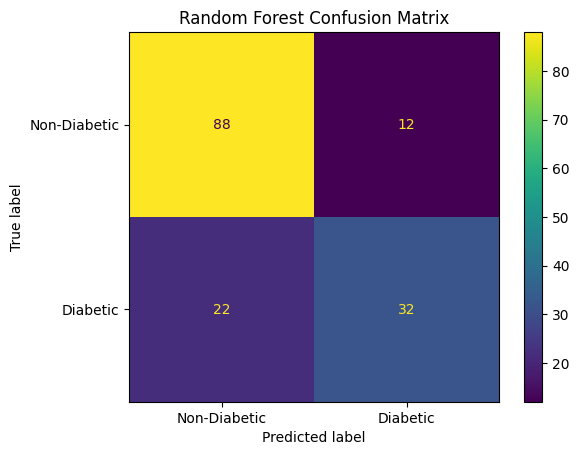

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [86]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.8191666666666666


In [87]:
patient_data = [[
    2,       # Pregnancies
    140,     # Glucose
    70,      # BloodPressure
    30,      # SkinThickness
    100,     # Insulin
    32.0,    # BMI
    0.5,     # DiabetesPedigreeFunction
    35       # Age
]]

In [88]:
prediction = rf_model.predict(patient_data)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [90]:
if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Non-Diabetic")

probability = rf_model.predict_proba(patient_data)[:, 1][0]
print(f"Model probability of class 1: {probability * 100:.2f}%")

Prediction: Diabetic
Model probability of class 1: 51.00%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 🩺 Diabetes Prediction for a New Patient

The trained Random Forest model can now be used to make a prediction
for a new patient.

The user provides the required patient information, and the model
predicts whether the patient is classified as Diabetic or
Non-Diabetic.

The model probability is also displayed as an additional indication
of the prediction.

In [91]:
pregnancies = float(input("Enter number of pregnancies: "))
glucose = float(input("Enter glucose level: "))
blood_pressure = float(input("Enter blood pressure: "))
skin_thickness = float(input("Enter skin thickness: "))
insulin = float(input("Enter insulin level: "))
bmi = float(input("Enter BMI: "))
pedigree = float(input("Enter Diabetes Pedigree Function: "))
age = float(input("Enter age: "))

Enter number of pregnancies: 2
Enter glucose level: 140
Enter blood pressure: 70
Enter skin thickness: 30
Enter insulin level: 100
Enter BMI: 32
Enter Diabetes Pedigree Function: 0.5
Enter age: 35


In [92]:
patient = [[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    pedigree,
    age
]]

In [93]:
prediction = rf_model.predict(patient)
probability = rf_model.predict_proba(patient)[0][1]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [94]:
print("\n==============================")
print("  DIABETES PREDICTION SYSTEM")
print("==============================")

if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Non-Diabetic")

print(f"Model probability: {probability * 100:.2f}%")

print("\nNote: This is an ML-based prediction,")
print("not a medical diagnosis.")


  DIABETES PREDICTION SYSTEM
Prediction: Diabetic
Model probability: 51.00%

Note: This is an ML-based prediction,
not a medical diagnosis.


# 📝 Conclusion

A machine learning based Diabetes Prediction System was successfully
developed using the Pima Indians Diabetes Dataset.

The data was cleaned and analyzed using Exploratory Data Analysis.
Logistic Regression and Random Forest were trained and compared.

Random Forest achieved the highest test accuracy of approximately
77.92%, with a ROC-AUC score of approximately 0.8192.

Feature importance analysis showed that Glucose was the most important
feature in the trained Random Forest model.

The final system accepts patient information and predicts whether the
patient is classified as Diabetic or Non-Diabetic.

This project demonstrates a complete medium-level machine learning
workflow, including data preprocessing, EDA, model training,
evaluation and prediction.

### ⚠️ Disclaimer

This project is developed for educational purposes only. It is not a
medical diagnostic system, and its predictions should not be used to
make medical decisions.